In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 60)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

DATA_DIR = Path('../../data/raw/markets')

with open(DATA_DIR / 'markets_flat_20260305_150828.json') as f:
    markets_raw = json.load(f)

df = pd.DataFrame(markets_raw)
print(f"Загружено: {len(df):,} рынков")
print(f"Колонок: {len(df.columns)}")
print(f"Размер в памяти: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Загружено: 50,896 рынков
Колонок: 114
Размер в памяти: 269.2 MB


In [2]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'fill_%': (df.notna().sum() / len(df) * 100).round(1),
    'example': df.iloc[0].values
})
print(info.to_string())

                                dtype  non_null  fill_%                                                                                                                                                                                                                                                                                                                                                example
id                                str     50896   100.0                                                                                                                                                                                                                                                                                                                                                 553856
question                          str     50896   100.0                                                                                                                                                   

In [3]:
numeric_cols = ['volume', 'liquidityClob', 'volume24hr', 'bestBid', 'bestAsk',
                '_event_volume_24hr']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

def safe_json_parse(val, default=None):
    """Gamma API возвращает некоторые поля как JSON-строки."""
    if default is None:
        default = []
    if isinstance(val, str):
        try:
            return json.loads(val)
        except (json.JSONDecodeError, TypeError):
            return default
    if isinstance(val, (list, dict)):
        return val
    return default

def parse_prices(x):
    parsed = safe_json_parse(x, [])
    if not isinstance(parsed, list):
        return []
    try:
        return [float(p) for p in parsed]
    except (ValueError, TypeError):
        return []

df['_prices'] = df['outcomePrices'].apply(parse_prices)
df['price_yes'] = df['_prices'].apply(lambda x: x[0] if x else np.nan)

df['_token_ids'] = df['clobTokenIds'].apply(lambda x: safe_json_parse(x, []))
df['n_tokens'] = df['_token_ids'].apply(len)

with open(DATA_DIR / 'events_20260305_150826.json') as f:
    events_raw = json.load(f)

event_tags = {}
for ev in events_raw:
    eid = str(ev.get('id', ''))
    tags = ev.get('tags', [])
    if isinstance(tags, list) and tags:

        labels = [t['label'] if isinstance(t, dict) else str(t) for t in tags]
        event_tags[eid] = labels
    else:
        event_tags[eid] = ['Unknown']

df['_tags'] = df['_event_id'].astype(str).map(event_tags).fillna('').apply(
    lambda x: x if isinstance(x, list) else ['Unknown']
)
df['category'] = df['_tags'].apply(lambda x: x[0] if x else 'Unknown')

df['spread'] = df['bestAsk'] - df['bestBid']
df['midpoint'] = (df['bestBid'] + df['bestAsk']) / 2
df['spread_pct'] = np.where(df['midpoint'] > 0, df['spread'] / df['midpoint'] * 100, np.nan)

for col in ['startDate', 'endDate', 'createdAt']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Подготовлено: {len(df):,} рынков")
print(f"С ценами: {df['price_yes'].notna().sum():,}")
print(f"Со спредом > 0: {(df['spread'] > 0).sum():,}")
print(f"С объёмом > 0: {(df['volume'] > 0).sum():,}")
print(f"Категорий: {df['category'].nunique()}")

Подготовлено: 50,896 рынков
С ценами: 36,844
Со спредом > 0: 50,896
С объёмом > 0: 19,725
Категорий: 409


In [4]:
summary_cols = ['volume', 'liquidityClob', 'volume24hr', 'bestBid', 'bestAsk',
                'spread', 'spread_pct', 'price_yes']
df[summary_cols].describe().round(3)

,volume,liquidityClob,volume24hr,bestBid,bestAsk,spread,spread_pct,price_yes
count,5.089600e+04,50896.000,5.089600e+04,50896.000,50896.000,50896.000,50896.000,36844.000
mean,8.743636e+04,9587.736,2.171370e+03,0.132,0.635,0.503,129.183,0.338
std,1.230115e+06,75553.375,6.921841e+04,0.230,0.392,0.443,78.801,0.261
min,0.000000e+00,0.000,0.000000e+00,0.000,0.001,0.001,0.100,0.000
25%,0.000000e+00,0.000,0.000000e+00,0.000,0.210,0.020,37.500,0.065
50%,0.000000e+00,96.739,0.000000e+00,0.030,0.870,0.570,170.557,0.410
75%,4.939830e+02,3208.095,0.000000e+00,0.110,1.000,1.000,200.000,0.500
max,8.690495e+07,5701752.772,1.266603e+07,0.999,1.000,1.000,200.000,1.000


In [5]:
vol = df['volume']
total_volume = vol.sum()

thresholds = [0, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]
labels = ['$0', '>$100', '>$1K', '>$10K', '>$100K', '>$1M', '>$10M']

print("=" * 55)
print(f"{'Порог':>10} | {'Рынков':>8} | {'% от всех':>8} | {'Совокупный V':>14}")
print("-" * 55)
for t, label in zip(thresholds, labels):
    mask = vol > t
    count = mask.sum()
    pct = count / len(df) * 100
    cumvol = vol[mask].sum()
    print(f"{label:>10} | {count:>8,} | {pct:>7.1f}% | ${cumvol:>13,.0f}")
print("=" * 55)
print(f"\nОбщий объём: ${total_volume:,.0f}")
print(f"Медиана: ${vol.median():,.0f}")
print(f"Среднее: ${vol.mean():,.0f}")
print(f"\n→ Большинство рынков 'мёртвые'. Для нас интересны рынки с volume > $10K.")

     Порог |   Рынков | % от всех |   Совокупный V
-------------------------------------------------------
        $0 |   19,725 |    38.8% | $4,450,161,077
     >$100 |   16,170 |    31.8% | $4,450,049,031
      >$1K |   10,731 |    21.1% | $4,447,729,561
     >$10K |    5,367 |    10.5% | $4,428,247,977
    >$100K |    1,955 |     3.8% | $4,307,200,981
      >$1M |      503 |     1.0% | $3,869,015,085
     >$10M |      117 |     0.2% | $2,462,337,921

Общий объём: $4,450,161,077
Медиана: $0
Среднее: $87,436

→ Большинство рынков 'мёртвые'. Для нас интересны рынки с volume > $10K.


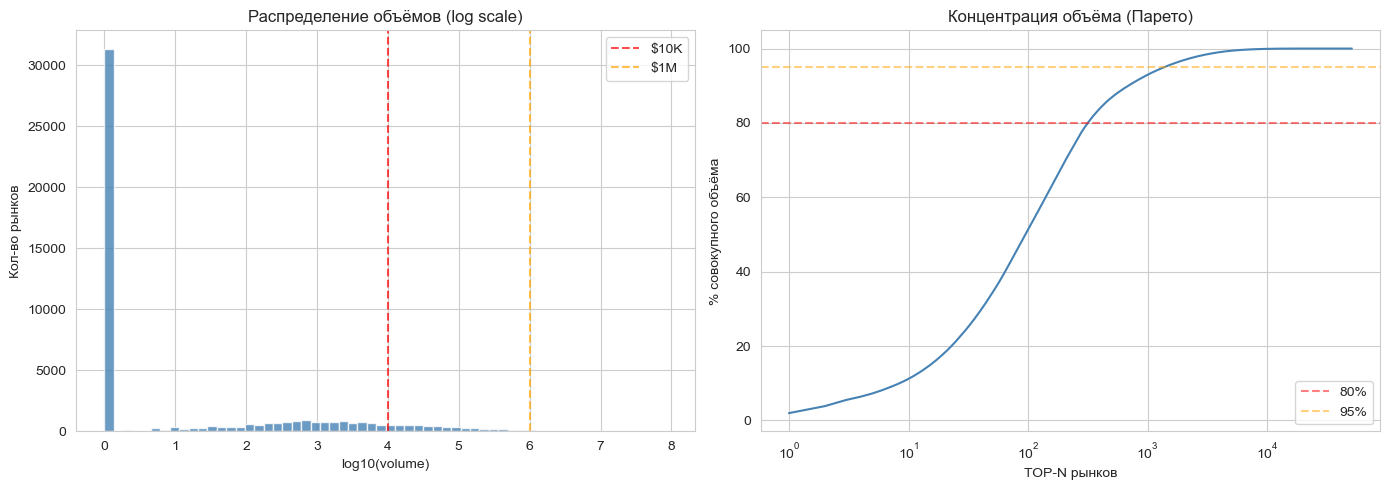

80% объёма сосредоточено в TOP-316 рынках (0.6%)
95% объёма сосредоточено в TOP-1374 рынках (2.7%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_vol = np.log10(df['volume'].clip(lower=1))
axes[0].hist(log_vol, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('log10(volume)')
axes[0].set_ylabel('Кол-во рынков')
axes[0].set_title('Распределение объёмов (log scale)')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='$10K')
axes[0].axvline(x=6, color='orange', linestyle='--', alpha=0.7, label='$1M')
axes[0].legend()

vol_sorted = df['volume'].sort_values(ascending=False).values
cum_pct = np.cumsum(vol_sorted) / vol_sorted.sum() * 100
axes[1].plot(range(1, len(cum_pct)+1), cum_pct, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('TOP-N рынков')
axes[1].set_ylabel('% совокупного объёма')
axes[1].set_title('Концентрация объёма (Парето)')
axes[1].set_xscale('log')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80%')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.5, label='95%')
axes[1].legend()

plt.tight_layout()
plt.show()

n_80 = np.searchsorted(cum_pct, 80) + 1
n_95 = np.searchsorted(cum_pct, 95) + 1
print(f"80% объёма сосредоточено в TOP-{n_80} рынках ({n_80/len(df)*100:.1f}%)")
print(f"95% объёма сосредоточено в TOP-{n_95} рынках ({n_95/len(df)*100:.1f}%)")

In [7]:
top20 = df.nlargest(20, 'volume')[['question', 'volume', 'liquidityClob',
                                     'volume24hr', 'spread', '_event_neg_risk', 'category']]
top20['volume'] = top20['volume'].apply(lambda x: f"${x:,.0f}")
top20['liquidityClob'] = top20['liquidityClob'].apply(lambda x: f"${x:,.0f}")
top20['volume24hr'] = top20['volume24hr'].apply(lambda x: f"${x:,.0f}")
top20['spread'] = top20['spread'].apply(lambda x: f"{x:.4f}")
top20.reset_index(drop=True)

,question,volume,liquidityClob,volume24hr,spread,_event_neg_risk,category
0,Will the Indiana Pacers win the 2026 NBA Finals?,"$86,904,949","$160,021","$12,666,031",0.0010,True,Sports
1,Will the Fed decrease interest rates by 50+ bps after th...,"$83,860,056","$3,684,203","$1,524,516",0.0010,True,Economy
2,Will the Fed increase interest rates by 25+ bps after th...,"$73,005,395","$1,665,913","$1,509,215",0.0010,True,Economy
3,Will Chelsea Clinton win the 2028 Democratic presidentia...,"$40,726,633","$468,942","$24,784",0.0010,True,World Elections
4,Will Leeds win the 2025–26 English Premier League?,"$38,359,350",$0,$0,0.0010,True,Sports
5,Will Jesus Christ return before 2027?,"$37,872,852","$1,829,067","$348,008",0.0010,False,Culture
6,Will Oprah Winfrey win the 2028 Democratic presidential ...,"$36,652,792","$2,047,459","$101,742",0.0010,True,World Elections
7,Will LeBron James win the 2028 US Presidential Election?,"$33,625,014","$751,979","$69,246",0.0010,True,World Elections
8,Will Tim Walz win the 2028 US Presidential Election?,"$33,190,547","$933,495","$159,195",0.0010,True,World Elections
9,Will George Clooney win the 2028 Democratic presidential...,"$32,965,879","$593,184","$56,033",0.0010,True,World Elections


In [8]:
cat_stats = df.groupby('category').agg(
    n_markets=('volume', 'size'),
    total_volume=('volume', 'sum'),
    median_volume=('volume', 'median'),
    avg_liquidity=('liquidityClob', 'mean'),
    total_24h=('volume24hr', 'sum'),
    neg_risk_pct=('_event_neg_risk', 'mean'),
).sort_values('total_volume', ascending=False)

cat_stats['volume_share'] = (cat_stats['total_volume'] / cat_stats['total_volume'].sum() * 100).round(1)

top_cats = cat_stats.head(15).copy()
top_cats['total_volume'] = top_cats['total_volume'].apply(lambda x: f"${x:,.0f}")
top_cats['median_volume'] = top_cats['median_volume'].apply(lambda x: f"${x:,.0f}")
top_cats['avg_liquidity'] = top_cats['avg_liquidity'].apply(lambda x: f"${x:,.0f}")
top_cats['total_24h'] = top_cats['total_24h'].apply(lambda x: f"${x:,.0f}")
top_cats['neg_risk_pct'] = (top_cats['neg_risk_pct'] * 100).round(1).astype(str) + '%'
top_cats['volume_share'] = top_cats['volume_share'].astype(str) + '%'
print(f"Всего категорий: {len(cat_stats)}")
top_cats

Всего категорий: 409


,n_markets,total_volume,median_volume,avg_liquidity,total_24h,neg_risk_pct,volume_share
category,,,,,,,
World Elections,618,"$1,128,763,847",$0,"$106,803","$7,580,214",100.0%,25.4%
Sports,16579,"$1,021,781,128",$0,"$8,147","$22,370,508",35.6%,23.0%
Soccer,1059,"$513,498,251",$0,"$48,021","$11,727,251",90.0%,11.5%
Politics,6181,"$481,518,815",$0,"$7,065","$13,444,591",90.1%,10.8%
Economy,217,"$219,060,882",$619,"$49,520","$6,656,131",91.2%,4.9%
Culture,1045,"$175,890,144",$418,"$15,717","$9,595,995",81.2%,4.0%
Trump-Machado,63,"$76,830,052",$0,"$15,606","$341,822",90.5%,1.7%
Geopolitics,184,"$72,479,917","$24,195","$17,460","$3,148,318",24.5%,1.6%
World,466,"$64,280,964",$357,"$18,203","$2,373,410",77.9%,1.4%


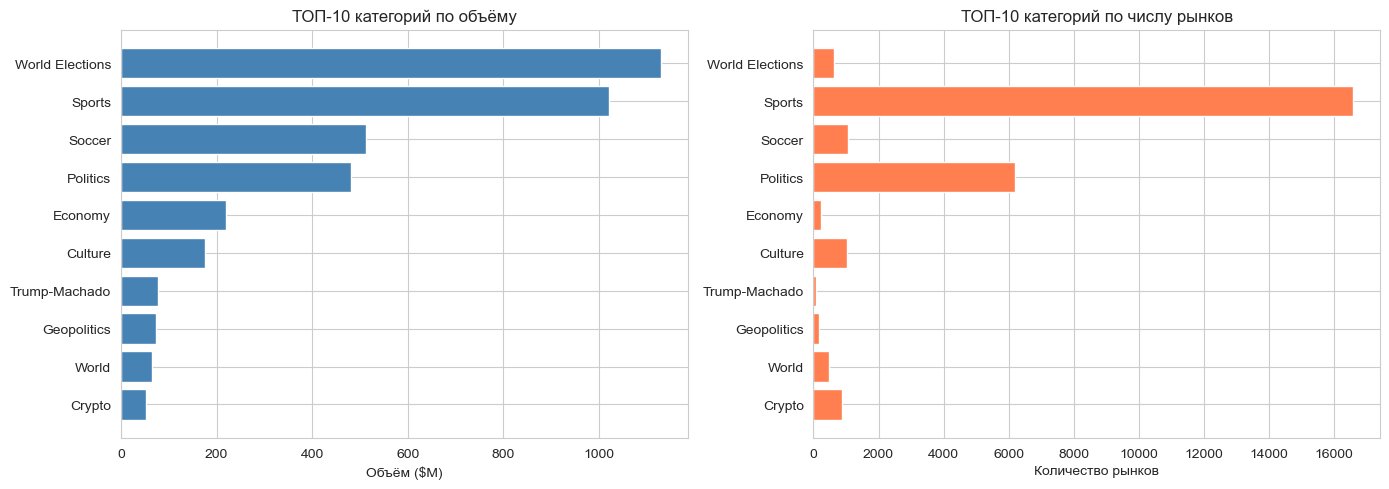

In [9]:
top10_cats = cat_stats.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_cats.index[::-1], top10_cats['total_volume'].values[::-1] / 1e6,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Объём ($M)')
axes[0].set_title('ТОП-10 категорий по объёму')

axes[1].barh(top10_cats.index[::-1], top10_cats['n_markets'].values[::-1],
             color='coral', edgecolor='white')
axes[1].set_xlabel('Количество рынков')
axes[1].set_title('ТОП-10 категорий по числу рынков')

plt.tight_layout()
plt.show()

In [10]:
neg = df['_event_neg_risk'] == True
print(f"NegRisk рынки: {neg.sum():,} ({neg.mean()*100:.1f}%)")
print(f"Обычные рынки: {(~neg).sum():,} ({(~neg).mean()*100:.1f}%)")
print()

comparison = pd.DataFrame({
    'NegRisk': df[neg][['volume', 'liquidityClob', 'volume24hr', 'spread']].describe().loc[['mean', '50%', 'max']].round(2).iloc[:, :].T.iloc[:, 0],
    'Regular': df[~neg][['volume', 'liquidityClob', 'volume24hr', 'spread']].describe().loc[['mean', '50%', 'max']].round(2).iloc[:, :].T.iloc[:, 0],
})

for label, mask in [('NegRisk', neg), ('Regular', ~neg)]:
    subset = df[mask]
    print(f"\n--- {label} ({mask.sum():,} markets) ---")
    print(f"  Объём средний:  ${subset['volume'].mean():>12,.0f}")
    print(f"  Объём медиана:  ${subset['volume'].median():>12,.0f}")
    print(f"  Объём макс:     ${subset['volume'].max():>12,.0f}")
    print(f"  Объём общий:    ${subset['volume'].sum():>12,.0f}  ({subset['volume'].sum()/df['volume'].sum()*100:.1f}%)")
    print(f"  Ликвидность ср: ${subset['liquidityClob'].mean():>12,.0f}")
    print(f"  24h volume:     ${subset['volume24hr'].sum():>12,.0f}")

NegRisk рынки: 29,944 (58.8%)
Обычные рынки: 20,952 (41.2%)


--- NegRisk (29,944 markets) ---
  Объём средний:  $     122,083
  Объём медиана:  $           0
  Объём макс:     $  86,904,949
  Объём общий:    $3,655,650,103  (82.1%)
  Ликвидность ср: $      11,174
  24h volume:     $  71,753,031

--- Regular (20,952 markets) ---
  Объём средний:  $      37,921
  Объём медиана:  $           0
  Объём макс:     $  37,872,852
  Объём общий:    $ 794,510,974  (17.9%)
  Ликвидность ср: $       7,321
  24h volume:     $  38,761,040


NegRisk events: 2674


Среднее отклонение суммы цен от $1.00: 0.2796
Медиана |отклонения|: 0.0450
Events с |откл| > 0.05: 1307
Events с |откл| > 0.10: 1103


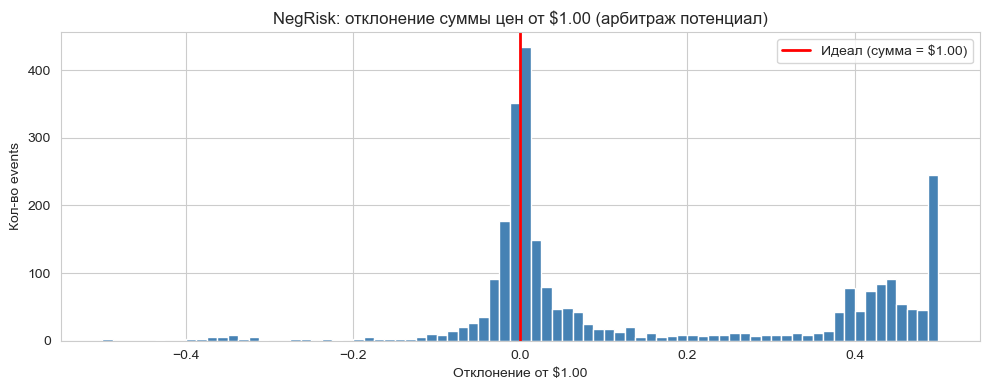


→ Положительное отклонение = рынок переоценён (можно продать всё). Отрицательное = недооценён (купить complete set дешевле $1).


In [11]:
neg_events = df[neg].groupby('_event_id').agg(
    title=('_event_title', 'first'),
    n_markets=('volume', 'size'),
    sum_prices=('price_yes', 'sum'),
    total_volume=('volume', 'sum'),
    total_liquidity=('liquidityClob', 'sum'),
).dropna(subset=['sum_prices'])

neg_events['deviation'] = neg_events['sum_prices'] - 1.0
neg_events['abs_deviation'] = neg_events['deviation'].abs()

print(f"NegRisk events: {len(neg_events)}")
print(f"Среднее отклонение суммы цен от $1.00: {neg_events['deviation'].mean():.4f}")
print(f"Медиана |отклонения|: {neg_events['abs_deviation'].median():.4f}")
print(f"Events с |откл| > 0.05: {(neg_events['abs_deviation'] > 0.05).sum()}")
print(f"Events с |откл| > 0.10: {(neg_events['abs_deviation'] > 0.10).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(neg_events['deviation'].clip(-0.5, 0.5), bins=80, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='red', linewidth=2, label='Идеал (сумма = $1.00)')
ax.set_xlabel('Отклонение от $1.00')
ax.set_ylabel('Кол-во events')
ax.set_title('NegRisk: отклонение суммы цен от $1.00 (арбитраж потенциал)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n→ Положительное отклонение = рынок переоценён (можно продать всё). "
      "Отрицательное = недооценён (купить complete set дешевле $1).")

Рынки с bid/ask: 33,756 из 50,896 (66.3%)


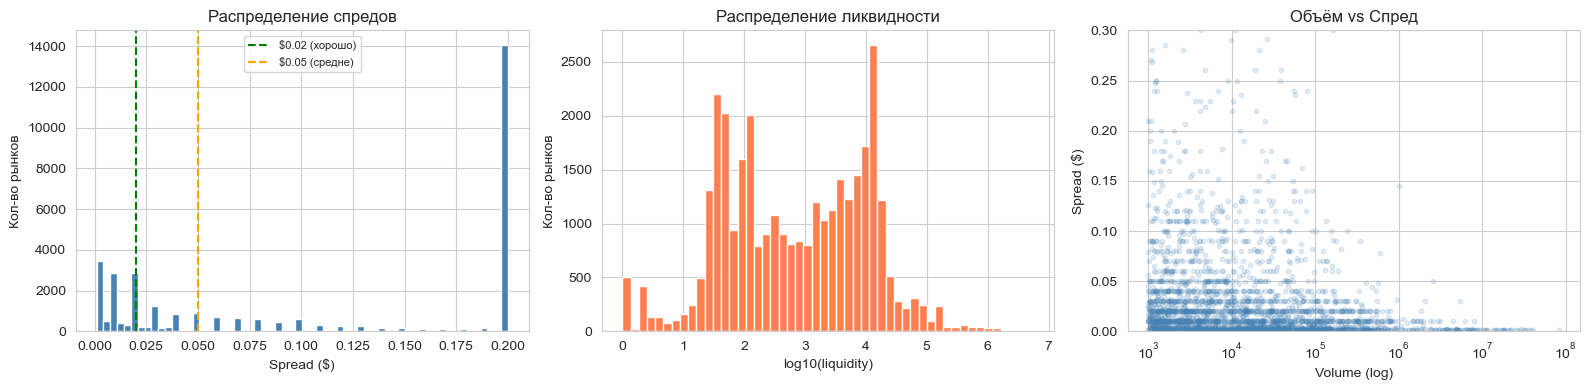


   Спред ≤ |   Рынков |  % от активных |    Ср. объём
-------------------------------------------------------
    $0.01 |    4,891 |          14.5% | $    630,232
    $0.02 |    8,347 |          24.7% | $    396,965
    $0.05 |   14,151 |          41.9% | $    241,556
    $0.10 |   17,651 |          52.3% | $    194,645


In [12]:
has_book = (df['bestBid'] > 0) & (df['bestAsk'] > 0)
df_active = df[has_book].copy()
print(f"Рынки с bid/ask: {len(df_active):,} из {len(df):,} ({len(df_active)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_active['spread'].clip(0, 0.2), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.02, color='green', linestyle='--', label='$0.02 (хорошо)')
axes[0].axvline(x=0.05, color='orange', linestyle='--', label='$0.05 (средне)')
axes[0].set_xlabel('Spread ($)')
axes[0].set_ylabel('Кол-во рынков')
axes[0].set_title('Распределение спредов')
axes[0].legend(fontsize=8)

log_liq = np.log10(df_active['liquidityClob'].clip(lower=1))
axes[1].hist(log_liq, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('log10(liquidity)')
axes[1].set_ylabel('Кол-во рынков')
axes[1].set_title('Распределение ликвидности')

sample = df_active[df_active['volume'] > 1000].sample(min(3000, len(df_active)), random_state=42)
axes[2].scatter(sample['volume'], sample['spread'], alpha=0.15, s=10, color='steelblue')
axes[2].set_xscale('log')
axes[2].set_xlabel('Volume (log)')
axes[2].set_ylabel('Spread ($)')
axes[2].set_title('Объём vs Спред')
axes[2].set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

spread_thresholds = [0.01, 0.02, 0.05, 0.10]
print(f"\n{'Спред ≤':>10} | {'Рынков':>8} | {'% от активных':>14} | {'Ср. объём':>12}")
print("-" * 55)
for t in spread_thresholds:
    mask = df_active['spread'] <= t
    n = mask.sum()
    avg_v = df_active.loc[mask, 'volume'].mean()
    print(f"    ${t:.2f} | {n:>8,} | {n/len(df_active)*100:>13.1f}% | ${avg_v:>11,.0f}")

Рынки со spread < 2x fee: 230 (0.7%)
  → средний объём: $1,588,900
  → средняя ликвидность: $119,154


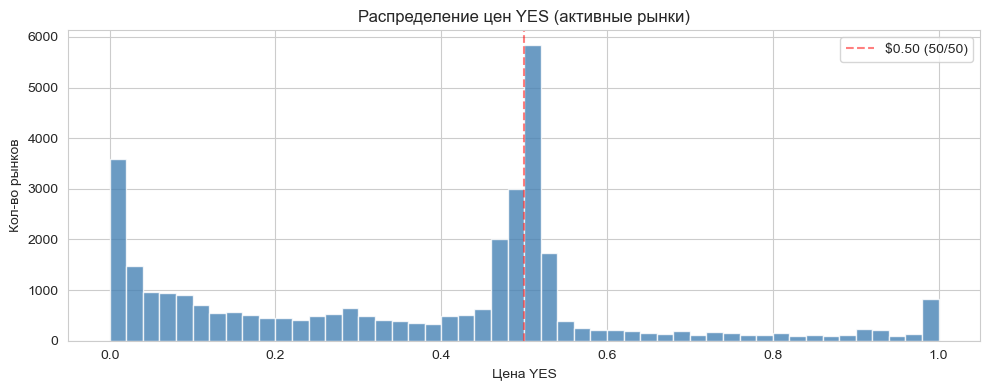


→ Много рынков с ценами близко к 0 или 1 = 'почти решённые'.
   Для трейдинга интереснее рынки в диапазоне 0.15-0.85 (неопределённость).


In [13]:
FEE_RATE = 0.02
df_active['fee'] = df_active['price_yes'] * (1 - df_active['price_yes']) * FEE_RATE
df_active['spread_vs_fee'] = df_active['spread'] / df_active['fee'].clip(lower=0.0001)

tradeable = df_active['spread'] < df_active['fee'] * 2
print(f"Рынки со spread < 2x fee: {tradeable.sum():,} ({tradeable.mean()*100:.1f}%)")
print(f"  → средний объём: ${df_active.loc[tradeable, 'volume'].mean():,.0f}")
print(f"  → средняя ликвидность: ${df_active.loc[tradeable, 'liquidityClob'].mean():,.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
prices = df_active['price_yes'].dropna()
ax.hist(prices, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Цена YES')
ax.set_ylabel('Кол-во рынков')
ax.set_title('Распределение цен YES (активные рынки)')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='$0.50 (50/50)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n→ Много рынков с ценами близко к 0 или 1 = 'почти решённые'.")
print(f"   Для трейдинга интереснее рынки в диапазоне 0.15-0.85 (неопределённость).")

In [14]:
filters = {
    'Все рынки': df,
    '+ bid/ask > 0': df[(df['bestBid'] > 0) & (df['bestAsk'] > 0)],
    '+ volume > $10K': df[(df['bestBid'] > 0) & (df['bestAsk'] > 0) & (df['volume'] > 10_000)],
    '+ spread < $0.05': df[(df['bestBid'] > 0) & (df['bestAsk'] > 0) & (df['volume'] > 10_000) & (df['spread'] < 0.05)],
    '+ liquidity > $1K': df[(df['bestBid'] > 0) & (df['bestAsk'] > 0) & (df['volume'] > 10_000) & (df['spread'] < 0.05) & (df['liquidityClob'] > 1_000)],
    '+ цена 0.05-0.95': df[(df['bestBid'] > 0) & (df['bestAsk'] > 0) & (df['volume'] > 10_000) & (df['spread'] < 0.05) & (df['liquidityClob'] > 1_000) & (df['price_yes'].between(0.05, 0.95))],
}

print(f"{'Фильтр':<25} | {'Рынков':>8} | {'Отсеяно':>10} | {'% объёма':>10}")
print("-" * 62)
prev = len(df)
for name, subset in filters.items():
    n = len(subset)
    vol_pct = subset['volume'].sum() / df['volume'].sum() * 100
    dropped = prev - n
    print(f"{name:<25} | {n:>8,} | {dropped:>+9,} | {vol_pct:>9.1f}%")
    prev = n

df_top = list(filters.values())[-1].copy()
print(f"\n{'='*62}")
print(f"Итого TOP рынков: {len(df_top):,}")
print(f"Объём: ${df_top['volume'].sum():,.0f} ({df_top['volume'].sum()/df['volume'].sum()*100:.1f}% от всего)")
print(f"Средний spread: ${df_top['spread'].mean():.4f}")
print(f"Средняя ликвидность: ${df_top['liquidityClob'].mean():,.0f}")

Фильтр                    |   Рынков |    Отсеяно |   % объёма
--------------------------------------------------------------
Все рынки                 |   50,896 |        +0 |     100.0%
+ bid/ask > 0             |   33,756 |   +17,140 |      77.5%
+ volume > $10K           |    4,304 |   +29,452 |      77.1%
+ spread < $0.05          |    3,796 |      +508 |      76.5%
+ liquidity > $1K         |    3,544 |      +252 |      75.5%
+ цена 0.05-0.95          |    1,662 |    +1,882 |      14.7%

Итого TOP рынков: 1,662
Объём: $656,041,399 (14.7% от всего)
Средний spread: $0.0187
Средняя ликвидность: $41,226


In [15]:
top30 = df_top.nlargest(30, 'volume')[
    ['question', 'volume', 'liquidityClob', 'spread', 'price_yes',
     'category', '_event_neg_risk']
].copy()
top30['volume'] = top30['volume'].apply(lambda x: f"${x:,.0f}")
top30['liquidityClob'] = top30['liquidityClob'].apply(lambda x: f"${x:,.0f}")
top30['spread'] = top30['spread'].apply(lambda x: f"${x:.3f}")
top30['price_yes'] = top30['price_yes'].apply(lambda x: f"{x:.2f}")
top30 = top30.reset_index(drop=True)
top30.index += 1
top30

,question,volume,liquidityClob,spread,price_yes,category,_event_neg_risk
1,Will Trump acquire Greenland before 2027?,"$29,187,580","$468,273",$0.002,0.11,Denmark,False
2,Will the Iranian regime fall by March 31?,"$19,607,481","$771,729",$0.003,0.15,Israel,False
3,Will the US confirm that aliens exist before 2027?,"$13,613,417","$2,341,888",$0.010,0.17,Culture,False
4,Will Iran close the Strait of Hormuz by March 31?,"$11,460,793","$214,236",$0.010,0.82,Foreign Policy,False
5,Russia x Ukraine ceasefire by end of 2026?,"$11,049,544","$296,934",$0.010,0.38,World,False
6,Will Gavin Newsom win the 2028 Democratic presidential n...,"$10,266,663","$691,249",$0.001,0.25,World Elections,True
7,Will China invade Taiwan by end of 2026?,"$10,123,319","$603,198",$0.001,0.11,Foreign Policy,False
8,Will the Colorado Avalanche win the 2026 NHL Stanley Cup?,"$9,777,342","$96,790",$0.001,0.21,Sports,True
9,Will Jesus Christ return before GTA VI?,"$9,747,010","$711,327",$0.010,0.48,Culture,False
10,Will the US acquire part of Greenland in 2026?,"$8,627,528","$166,283",$0.010,0.17,Politics,False


In [16]:
top_markets_export = df_top.nlargest(500, 'volume')[
    ['conditionId', 'clobTokenIds', 'question', 'volume', 'liquidityClob',
     'spread', 'price_yes', 'category', '_event_id', '_event_neg_risk']
].copy()

output_path = Path('../../data/processed/top_markets_for_collection.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
top_markets_export.to_json(output_path, orient='records', indent=2)
print(f"Сохранено: {len(top_markets_export)} TOP рынков → {output_path}")
print(f"Общий объём выбранных: ${top_markets_export['volume'].sum():,.0f}")

Сохранено: 500 TOP рынков → ../../data/processed/top_markets_for_collection.json
Общий объём выбранных: $598,342,000
